# Prédiction du prix d'une voiture d'occasion

**Objectif :** construire un modèle de régression qui estime le prix de vente d'une voiture à partir de ses caractéristiques, puis mesurer sa précision.

**Données :** *Vehicle dataset from CarDekho* (Kaggle) — 301 véhicules, prix d'origine en lakhs de roupies indiennes, **convertis en ouguiyas mauritaniens (MRU)** dès le chargement.

Plan (une section = une étape du sujet) :
1. Comprendre le problème
2. Charger et explorer
3. Visualiser
4. Nettoyer et préparer
5. Séparer les données
6. Modèle de référence (régression linéaire)
7. Modèles plus puissants (arbre, forêt aléatoire)
8. Interpréter

In [6]:
import datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

SEED = 42  # graine fixe : mêmes résultats à chaque exécution
pd.set_option("display.float_format", "{:,.2f}".format)

## Étape 1 — Comprendre le problème

- **Variable cible :** `Selling_Price` (prix de vente).
- **Variables explicatives :** année (→ âge), kilométrage, prix à neuf (`Present_Price`), carburant, type de vendeur, boîte de vitesses, nombre de propriétaires.

**Hypothèses à vérifier :**
- Une voiture **plus ancienne** est moins chère.
- Une voiture **plus kilométrée** est moins chère.
- Le **prix à neuf** est très lié au prix de vente.
- Les voitures **diesel** et **automatiques** sont plus chères.

## Étape 2 — Charger et explorer

Le CSV est lu directement depuis une copie publique du jeu Kaggle (aucun téléversement nécessaire).
Si le lien ne fonctionne pas : téléchargez `car data.csv` sur Kaggle, déposez-le dans Colab (icône dossier) et remplacez l'URL par `"car data.csv"`.

In [2]:
URL = "https://raw.githubusercontent.com/krishnaik06/Car-Price-Prediction/master/car%20data.csv"
df = pd.read_csv(URL)
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


### Conversion des prix en ouguiyas (MRU)

Les prix du fichier sont en **lakhs** de roupies indiennes (1 lakh = 100 000 ₹). On les convertit en MRU :

$$\text{prix}_{MRU} = \text{prix}_{lakhs} \times 100\,000 \times \text{taux}_{INR \to MRU}$$

Avec un taux d'environ **1 ₹ ≈ 0,42 MRU** (octobre 2026), **1 lakh ≈ 42 000 MRU**.
Le taux varie : modifiez `TAUX_INR_MRU` pour le mettre à jour. La conversion ne change pas la qualité des modèles (le R² reste identique), seulement l'unité des erreurs.

In [3]:
TAUX_INR_MRU = 0.42   # 1 roupie indienne = 0,42 ouguiya (octobre 2026)
LAKH = 100_000        # 1 lakh = 100 000 roupies

for col in ["Selling_Price", "Present_Price"]:
    df[col] = df[col] * LAKH * TAUX_INR_MRU

df[["Car_Name", "Selling_Price", "Present_Price"]].head()

,Car_Name,Selling_Price,Present_Price
0,ritz,140700.0,234780.0
1,sx4,199500.0,400680.0
2,ciaz,304500.0,413700.0
3,wagon r,119700.0,174300.0
4,swift,193200.0,288540.0


In [4]:
print("Dimensions :", df.shape)
print("\nTypes des colonnes :")
print(df.dtypes)
print("\nValeurs manquantes :", df.isna().sum().sum())
print("Doublons :", df.duplicated().sum())

Dimensions : (301, 9)

Types des colonnes :
Car_Name          object
Year               int64
Selling_Price    float64
Present_Price    float64
Kms_Driven         int64
Fuel_Type         object
Seller_Type       object
Transmission      object
Owner              int64
dtype: object

Valeurs manquantes : 0
Doublons : 2


In [7]:
df.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.00,301.00,301.00,301.00,301.00
mean,"2,013.63","195,774.42","320,395.81","36,947.21",0.04
std,2.89,"213,478.09","363,052.85","38,886.88",0.25
min,"2,003.00","4,200.00","13,440.00",500.00,0.00
25%,"2,012.00","37,800.00","50,400.00","15,000.00",0.00
50%,"2,014.00","151,200.00","268,800.00","32,000.00",0.00
75%,"2,016.00","252,000.00","415,800.00","48,767.00",0.00
max,"2,018.00","1,470,000.00","3,889,200.00","500,000.00",3.00


In [8]:
for col in ["Fuel_Type", "Seller_Type", "Transmission", "Owner"]:
    print(df[col].value_counts(), "\n")

Fuel_Type
Petrol    239
Diesel     60
CNG         2
Name: count, dtype: int64 

Seller_Type
Dealer        195
Individual    106
Name: count, dtype: int64 

Transmission
Manual       261
Automatic     40
Name: count, dtype: int64 

Owner
0    290
1     10
3      1
Name: count, dtype: int64 



**Constats :**
- 301 lignes, 9 colonnes, **aucune valeur manquante**, **2 doublons** à supprimer.
- `Kms_Driven` a un maximum de 500 000 km, très loin du reste (75 % des véhicules < 50 000 km) → valeur suspecte.
- `Car_Name` contient 98 noms différents pour 301 lignes.

## Étape 3 — Visualiser

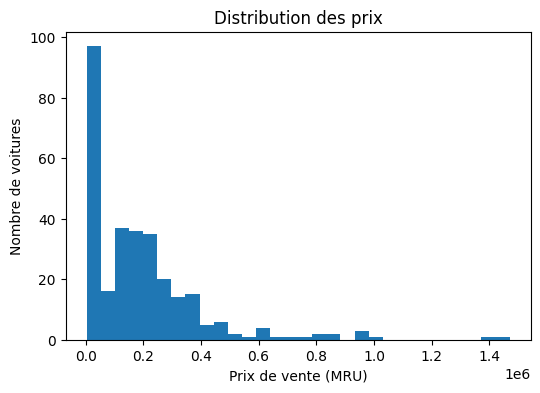

In [9]:
plt.figure(figsize=(6, 4))
plt.hist(df["Selling_Price"], bins=30)
plt.xlabel("Prix de vente (MRU)")
plt.ylabel("Nombre de voitures")
plt.title("Distribution des prix")
plt.show()

La plupart des voitures coûtent moins de 420 000 MRU ; quelques véhicules haut de gamme (> 840 000 MRU) forment une longue traîne à droite. Cette asymétrie sera traitée à l'étape 4 (passage au logarithme).

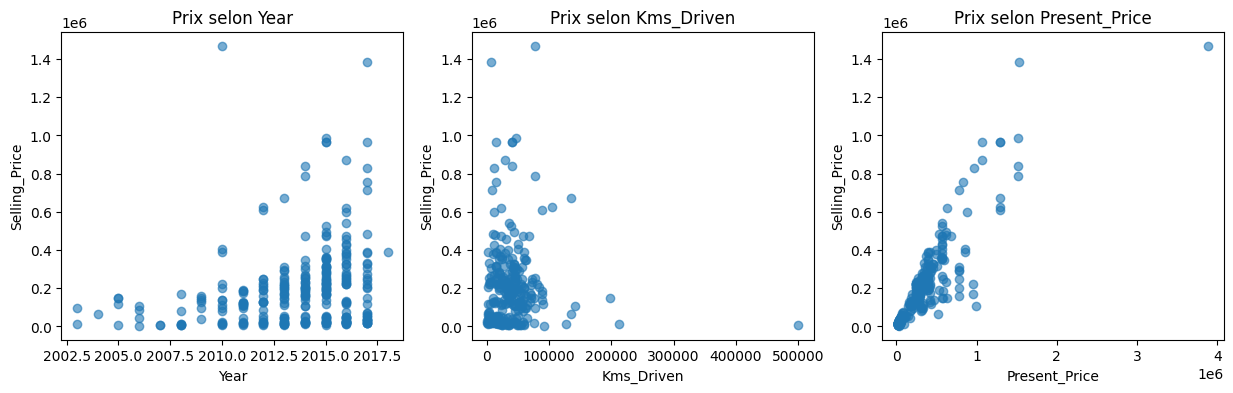

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["Year", "Kms_Driven", "Present_Price"]):
    ax.scatter(df[col], df["Selling_Price"], alpha=0.6)
    ax.set_xlabel(col)
    ax.set_ylabel("Selling_Price")
    ax.set_title(f"Prix selon {col}")
plt.show()

- **Année :** les voitures récentes sont plus chères → hypothèse confirmée.
- **Kilométrage :** tendance à la baisse mais faible ; un point isolé à 500 000 km.
- **Prix à neuf :** relation presque linéaire avec le prix de vente → variable très informative.

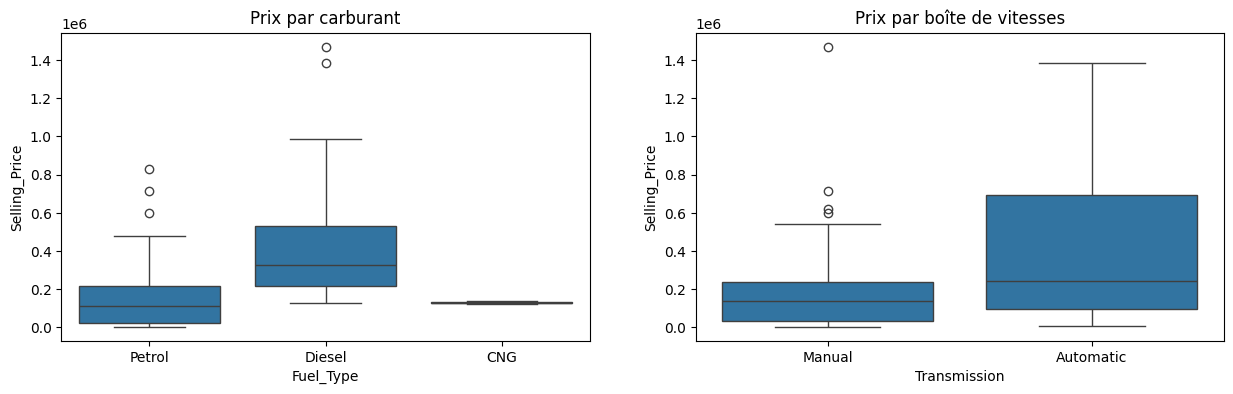

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))
sns.boxplot(data=df, x="Fuel_Type", y="Selling_Price", ax=axes[0])
sns.boxplot(data=df, x="Transmission", y="Selling_Price", ax=axes[1])
axes[0].set_title("Prix par carburant")
axes[1].set_title("Prix par boîte de vitesses")
plt.show()

Les voitures **diesel** et **automatiques** sont en moyenne plus chères → hypothèse confirmée.

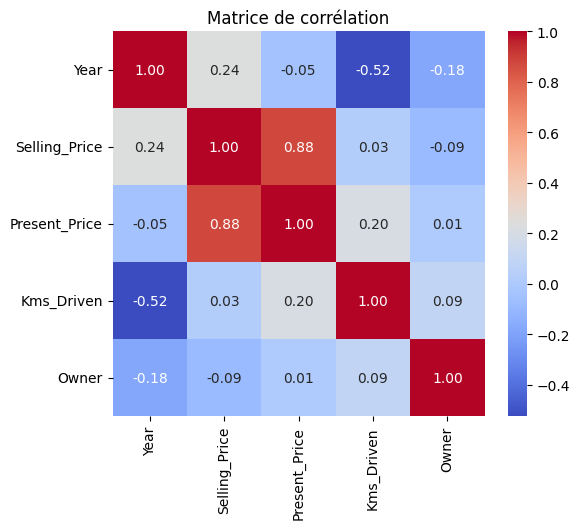

In [14]:
plt.figure(figsize=(6, 5))
sns.heatmap(df.select_dtypes("number").corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Matrice de corrélation")
plt.show()

- `Present_Price` est la variable la plus corrélée au prix (≈ 0,88).
- `Year` est corrélée positivement (plus récent = plus cher).

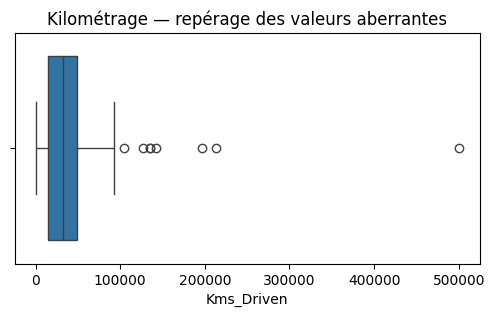

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
196,Activa 3g,2008,"7,140.00","21,840.00",500000,Petrol,Individual,Automatic,0


In [15]:
plt.figure(figsize=(6, 3))
sns.boxplot(x=df["Kms_Driven"])
plt.title("Kilométrage — repérage des valeurs aberrantes")
plt.show()

df[df["Kms_Driven"] > 300_000]

**Valeur aberrante :** un scooter *Activa 3g* avec 500 000 km — invraisemblable, probablement une erreur de saisie. On le supprimera.

Les voitures très chères (Land Cruiser, Fortuner) sont en revanche **de vraies observations** : on les garde.

## Étape 4 — Nettoyer et préparer

1. Supprimer les doublons.
2. Supprimer la valeur aberrante de kilométrage.
3. Créer la variable **âge** = année actuelle − année du véhicule.
4. Supprimer `Car_Name` : les noms sont incohérents (souvent le modèle sans la marque : *ritz*, *city*…), donc la marque n'est pas extractible de façon fiable, et 98 valeurs pour ~300 lignes créeraient trop de colonnes.
5. Encoder les variables catégorielles en colonnes de 0 et 1 (*one-hot encoding*).
6. Passer les prix (`Selling_Price`, `Present_Price`) au **logarithme**.

In [31]:
data = df.drop_duplicates()
data = data[data["Kms_Driven"] < 300_000]

data["Age"] = datetime.date.today().year - data["Year"]

names = data["Car_Name"]  # conservé à part pour analyser les erreurs à la fin
data = data.drop(columns=["Car_Name", "Year"])

print("Lignes après nettoyage :", len(data))

Lignes après nettoyage : 298


In [32]:
data = pd.get_dummies(data, columns=["Fuel_Type", "Seller_Type", "Transmission"],
                      drop_first=True, dtype=int)
data.head()

,Selling_Price,Present_Price,Kms_Driven,Owner,Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
0,"140,700.00","234,780.00",27000,0,12,0,1,0,1
1,"199,500.00","400,680.00",43000,0,13,1,0,0,1
2,"304,500.00","413,700.00",6900,0,9,0,1,0,1
3,"119,700.00","174,300.00",5200,0,15,0,1,0,1
4,"193,200.00","288,540.00",42450,0,12,1,0,0,1


**Pourquoi le logarithme des prix ?**

Une voiture perd chaque année un **pourcentage** de sa valeur, pas un montant fixe : une voiture de 1 260 000 MRU perd beaucoup plus qu'une voiture de 126 000 MRU.
Le logarithme transforme ces pourcentages en différences simples, ce qu'une régression linéaire sait modéliser. Il réduit aussi la longue traîne vue sur l'histogramme.

Les modèles apprennent donc `log(prix)` ; on revient en MRU avec `exp()` **avant** de calculer les métriques, qui restent ainsi dans l'unité du prix.

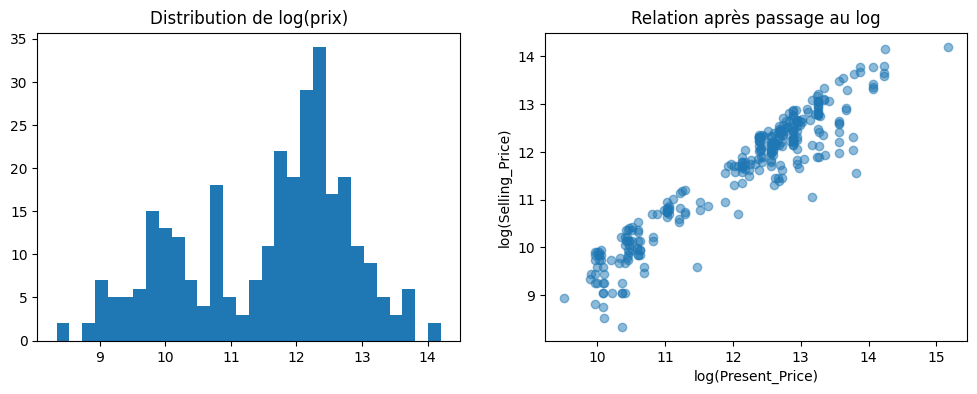

In [33]:
data["Present_Price"] = np.log(data["Present_Price"])
data["Selling_Price"] = np.log(data["Selling_Price"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(data["Selling_Price"], bins=30)
axes[0].set_title("Distribution de log(prix)")
axes[1].scatter(data["Present_Price"], data["Selling_Price"], alpha=0.5)
axes[1].set_xlabel("log(Present_Price)")
axes[1].set_ylabel("log(Selling_Price)")
axes[1].set_title("Relation après passage au log")
plt.show()

La distribution est plus équilibrée et la relation avec le prix à neuf devient une droite bien nette.

## Étape 5 — Séparer les données

80 % pour l'entraînement, 20 % pour le test, avec une graine fixe. Le jeu de test n'est utilisé **que pour l'évaluation finale**.

In [34]:
X = data.drop(columns="Selling_Price")
y = data["Selling_Price"]  # log du prix

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)
print("Entraînement :", X_train.shape, "| Test :", X_test.shape)

Entraînement : (238, 8) | Test : (60, 8)


## Étape 6 — Modèle de référence : régression linéaire

Métriques utilisées :
- **MAE** : erreur moyenne, dans l'unité du prix (MRU).
- **RMSE** : comme la MAE, mais pénalise davantage les grosses erreurs.
- **R²** : part de la variation des prix expliquée par le modèle (1 = parfait).

Les prédictions sont repassées en MRU (`np.exp`) avant le calcul.

On calcule le R² sur l'entraînement **et** sur le test pour détecter le sur-apprentissage.

In [35]:
def evaluate(name, model):
    model.fit(X_train, y_train)
    real = np.exp(y_test)                     # retour en MRU
    pred = np.exp(model.predict(X_test))
    return {
        "Modèle": name,
        "MAE": mean_absolute_error(real, pred),
        "RMSE": np.sqrt(mean_squared_error(real, pred)),
        "R² test": r2_score(real, pred),
        "R² entraînement": r2_score(np.exp(y_train), np.exp(model.predict(X_train))),
    }

lin = LinearRegression()
pd.DataFrame([evaluate("Régression linéaire", lin)]).round({"MAE": 0, "RMSE": 0, "R² test": 3, "R² entraînement": 3})

,Modèle,MAE,RMSE,R² test,R² entraînement
0,Régression linéaire,"26,417.00","42,036.00",0.96,0.98


## Étape 7 — Modèles plus puissants

- **Arbre de décision** : découpe les données par questions successives (« âge < 5 ? »…). Sans limite de profondeur, il peut apprendre les données par cœur.
- **Forêt aléatoire** : moyenne de nombreux arbres entraînés sur des échantillons différents → plus stable, moins de sur-apprentissage.

In [36]:
tree = DecisionTreeRegressor(random_state=SEED)
forest = RandomForestRegressor(n_estimators=200, random_state=SEED)

results = pd.DataFrame([
    evaluate("Régression linéaire", lin),
    evaluate("Arbre de décision", tree),
    evaluate("Forêt aléatoire", forest),
]).set_index("Modèle").round({"MAE": 0, "RMSE": 0, "R² test": 3, "R² entraînement": 3})
results

,MAE,RMSE,R² test,R² entraînement
Modèle,,,,
Régression linéaire,"26,417.00","42,036.00",0.96,0.98
Arbre de décision,"49,308.00","90,943.00",0.83,1.00
Forêt aléatoire,"56,637.00","123,580.00",0.68,0.97


**Lecture du tableau comparatif :**
- La **régression linéaire** est la meilleure sur le test (R² ≈ 0,96, erreur moyenne ≈ 26 000 MRU) : c'est le modèle retenu. L'objectif du sujet (R² test > 0,80) est atteint.
- L'**arbre de décision** a un R² d'entraînement de 1,00 (il a appris les données par cœur) mais un R² test bien plus bas : c'est du **sur-apprentissage**.
- La **forêt aléatoire** montre aussi un grand écart entraînement/test. Un arbre ne fait que des *moyennes* de voitures déjà vues ; avec ~240 voitures d'entraînement et très peu de modèles chers, il estime mal les cas rares. La régression linéaire, elle, applique la même règle « prix à neuf × dépréciation selon l'âge » à toutes les voitures.

Conclusion : un modèle plus complexe n'est pas toujours meilleur, surtout sur un petit jeu de données.

## Étape 8 — Interpréter

### Importance des variables

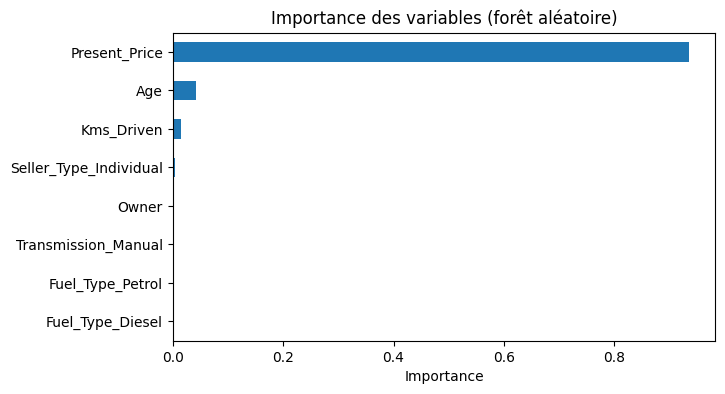

Régression linéaire : chaque année d'âge fait perdre environ 9 % de la valeur.


In [37]:
importances = pd.Series(forest.feature_importances_, index=X.columns).sort_values()
importances.plot.barh(figsize=(7, 4), title="Importance des variables (forêt aléatoire)")
plt.xlabel("Importance")
plt.show()

coefs = pd.Series(lin.coef_, index=X.columns)
print(f"Régression linéaire : chaque année d'âge fait perdre environ {(1 - np.exp(coefs['Age'])) * 100:.0f} % de la valeur.")

- Le **prix à neuf** domine : une voiture chère neuve reste chère d'occasion.
- L'**âge** vient ensuite : la voiture perd un pourcentage de sa valeur chaque année.
- Le kilométrage, le carburant, la boîte et le vendeur jouent un rôle secondaire.
- Les deux hypothèses de l'étape 1 (âge et prix à neuf) sont confirmées ; l'effet du kilométrage est plus faible que prévu.

### Prix prédits vs prix réels (régression linéaire)

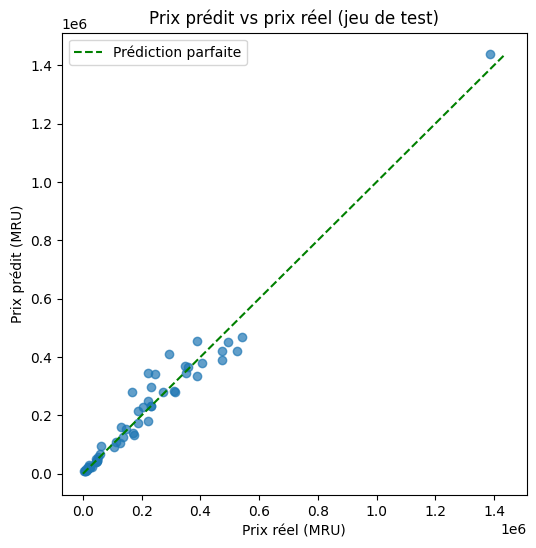

In [41]:
real = np.exp(y_test)
pred = np.exp(lin.predict(X_test))

plt.figure(figsize=(6, 6))
plt.scatter(real, pred, alpha=0.7)
lim = [0, max(real.max(), pred.max()) + 1]
plt.plot(lim, lim, "g--", label="Prédiction parfaite")
plt.xlabel("Prix réel (MRU)")
plt.ylabel("Prix prédit (MRU)")
plt.title("Prix prédit vs prix réel (jeu de test)")
plt.legend()
plt.show()

Plus les points sont proches de la diagonale rouge, meilleure est la prédiction. Les points sont bien alignés, avec un écart plus grand pour les voitures chères.

### Analyse des plus grosses erreurs

In [42]:
errors = pd.DataFrame({
    "Voiture": names.loc[X_test.index],
    "Âge": X_test["Age"],
    "Km": X_test["Kms_Driven"],
    "Prix neuf": np.exp(X_test["Present_Price"]).round(),
    "Prix réel": real.round(),
    "Prix prédit": pred.round(),
})
errors["Erreur"] = errors["Prix prédit"] - errors["Prix réel"]

errors.reindex(errors["Erreur"].abs().sort_values(ascending=False).index).head(5)

,Voiture,Âge,Km,Prix neuf,Prix réel,Prix prédit,Erreur
78,corolla altis,16,80000,"958,860.00","220,500.00","343,958.00","123,458.00"
60,corolla altis,13,40001,"781,620.00","291,900.00","409,024.00","117,124.00"
94,corolla altis,18,89000,"956,760.00","168,000.00","278,522.00","110,522.00"
83,innova,11,38000,"565,320.00","525,000.00","419,910.00","-105,090.00"
95,corolla altis,14,72000,"781,620.00","245,700.00","340,129.00","94,429.00"


**Pourquoi ces voitures sont-elles mal estimées ?**
- La plupart sont des **Corolla Altis surestimées** : ce modèle perd sa valeur plus vite que la moyenne, alors que l'**Innova**, sous-estimée, la garde mieux. Le modèle ne connaît pas le nom de la voiture (colonne supprimée), il applique donc la même dépréciation à toutes.
- Ce sont des voitures **chères à l'achat** : en MRU, les erreurs sont naturellement plus grandes quand le prix est élevé, et le jeu de données contient peu de voitures haut de gamme.

## Conclusion

- Modèle retenu : **régression linéaire sur le log des prix**, R² test ≈ 0,96 (objectif > 0,80 atteint).
- Les variables qui comptent le plus sont le **prix à neuf** et l'**âge** du véhicule.
- Les modèles d'arbres sur-apprennent sur ce petit jeu de données.
- Pistes d'amélioration : ajouter la marque / le modèle avec un jeu de données aux noms propres (les erreurs le montrent), plus de voitures haut de gamme, limiter la profondeur des arbres.